In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pybaselines import Baseline, utils
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os 
import glob
from galvani import BioLogic as BL

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio # For Plotly themes 
from datetime import datetime, timedelta

C:\Users\b1104371\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Function for reading files

In [2]:
def read_data(file_name):
    legend_temp = []
    data_line_temp = []
    time_stamp_temp = []
    data_storing = False
    print(f"Reading file: {file_name}")
    with open(file_name, 'r') as file:
        for line in file:
            if 'q(A-1)' in line:
                data_storing = True
                continue
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2] 
            if data_storing:
                data_line_temp.append(line.strip())
    df_temp= pd.DataFrame([line.split() for line in data_line_temp])
    df_temp= df_temp.astype(float)

    return legend_temp, time_stamp_temp ,df_temp

    

# Function for finding timestamps

In [3]:
def find_nearest_time(target_time, discharge_start_time, total_cycle_time, time_dict):
    new_time_dict = {}

    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
#     print(new_time_dict)
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    discharge_time_difference = min(new_time_dict, key=lambda x: abs(x - (target_time+discharge_start_time)))
    discharge_key = new_time_dict[discharge_time_difference]
    
    furthest_time_difference = min(new_time_dict, key=lambda x: abs(x - (target_time+total_cycle_time)))
    furthest_key = new_time_dict[furthest_time_difference]
    
    return nearest_key, discharge_key, furthest_key, new_time_dict

# Fitting Functions

In [4]:
def lorentzian(x, a, x0, w0):
    return a* w0**2 / (w0**2 + (x - x0)**2)

"""def multi_lorentzian(x, *params):
    mean_positions = [18.6, 19.5, 20.8]
    y = np.zeros_like(x)
    j = 0
    for i in range(0, len(params),2):
        a = params[i]
    #    x0 = params[i+1]
        x0 = mean_positions[j]
        w0 = params[i+1]
        y += lorentzian(x, a, x0, w0)
        j+=1
    return y"""

def multi_lorentzian(x, *params):
    mean_positions = [18.6, 19.13, 19.5, 19.9, 20.8]
    # mean_positions = [18.6, 19.13, 19.9, 20.8]
    # mean_positions = [18.6, 19.5, 20.8]
    # mean_positions = [19.5]

    y = np.zeros_like(x)
    for j in range(len(mean_positions)):
        x0 = mean_positions[j]
        a  = params[2*j]
        w0 = params[2*j+1]
        y += lorentzian(x, a, x0, w0)
    return y

# Read all the files

In [51]:
#os.chdir(r'.\data\Test_data\20240604_2503-SKJB_6MECDEC_100volHFE')
#mpr = BL.MPRfile('./2503-SKJB-1pt07mg_6MECDEC_100volHFE-1_C02.mpr')
os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\After_Beamtime\1705-SSup\20240610_1705-SSuP_satDME_400HFE\20240610_1705_SSuP_satDME_400HFE')
mpr = BL.MPRfile('./1705-SSuP_satDME_400HFE_1pt04mg_C02.mpr')

file_list = glob.glob('*_1_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)

    
print('Number of files:',key)

Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00001.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00002.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00003.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00004.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00005.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00006.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00007.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00008.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00009.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00010.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00011.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00012.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00013.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00014.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00015.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00016.dat
Reading file: 20240610_1705_SSuP_satDME_400HFE_1_00017.d

In [5]:
pio.templates.default = "simple_white"
fig = go.Figure()
for key in file_dictionary:
    X_data = file_dictionary[key].iloc[:,0]
    Y_data = file_dictionary[key].iloc[:,1]
    fig.add_trace(go.Scatter(x = X_data, y = Y_data))

fig.show()

NameError: name 'file_dictionary' is not defined

# Read EC lab files 

Indices for cycle change: [0, 3387, 6447, 9695, 12536, 12788]


Text(0, 0.5, 'Potential (V)')

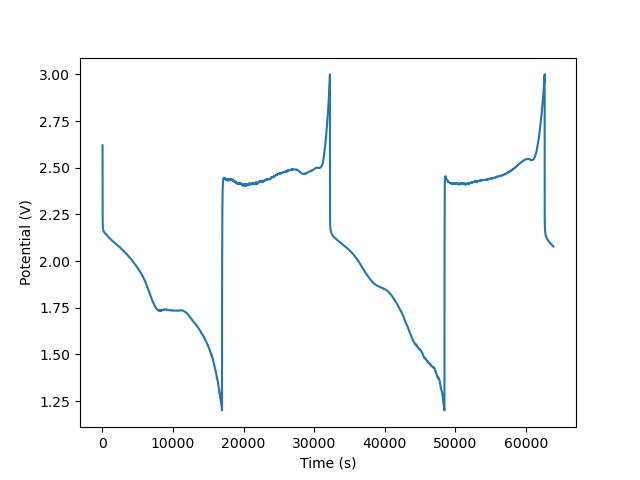

In [52]:
#mpr = BL.MPRfile('./2503-SKJB-1pt07mg_6MECDEC_100volHFE-1_C02.mpr')

elec_df_temp = pd.DataFrame(mpr.data)
#print(elec_df_temp)

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
cycle_change_index.append(0)
for index in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[index] != elec_df['Ns'].iloc[index+1]:
        cycle_change_index.append(index)
cycle_change_index.append(index+1) #Takes the index for the last file also  
print("Indices for cycle change:", cycle_change_index)

    # Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.figure()
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')

# Data Segregation

In [54]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))

# Initial and final line numbers for the chosen cycle to plot:
initial_line = cycle_change_index[2*starting_cycle-2]
change_cycle_line = cycle_change_index[2*starting_cycle-1]
final_line = cycle_change_index[2*end_cycle]
print('\nBiologic data file line details:')
print('initial_line,change_cycle_line, final_line:',initial_line,change_cycle_line, final_line)

elec_df_2 = elec_df.iloc[initial_line:final_line]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

time_when_change = elec_df.iloc[change_cycle_line].loc['time/s']
print("\ntime when cycle change:",time_when_change)

# Reference times to segregate SAXS data files
ref_time = int(elec_df_2['time/s'].iloc[0] - elec_df['time/s'].iloc[0])
total_cycle_time = int(elec_df_2['time/s'].iloc[-1] - int(elec_df_2['time/s'].iloc[0]))
discharge_start_time = int(time_when_change - elec_df_2['time/s'].iloc[0])
print()
print(f'Ref. time, relative discharge start and Total cycle time:{ref_time}s, {discharge_start_time} and {total_cycle_time}s\n')

# find the corresponding starting abd ending SAXS file
starting_file, discharge_file, last_file, new_time_dict  = find_nearest_time(ref_time, discharge_start_time, total_cycle_time, time_stamp)

print(f"Starting SAXS file no.: {starting_file}")
print(f"Discharge SAXS file no.: {discharge_file}")
print(f"Last SAXS file no.: {last_file}\n")
print('Time stamps:')
print('Initial file:',time_stamp[starting_file], "Discharge file:",time_stamp[discharge_file],'Last file:', time_stamp[last_file])

Total number of cycles: 3

Biologic data file line details:
initial_line,change_cycle_line, final_line: 0 3387 12536

time when cycle change: 16935.795141072434

Ref. time, relative discharge start and Total cycle time:0s, 16925 and 62633s

Starting SAXS file no.: 1
Discharge SAXS file no.: 85
Last SAXS file no.: 311

Time stamps:
Initial file: 2024-06-10T16:20:43 Discharge file: 2024-06-10T21:03:23 Last file: 2024-06-11T09:44:11


# For Baseline correction (manually select the first long exposure file)

In [5]:

background_file = glob.glob('*_Al_WAXS.dat')
for input in background_file:
    a1,a2,background = read_data(input)


Reading file: beckground_with_Al_WAXS.dat


# Creating the background (With a average over the first three files)

[0.00388379 0.00403782 0.00418544 ... 0.00050796 0.00043301 0.00035404]


'plt.xlim(15,22)\nplt.ylim(-0.001,0.008)'

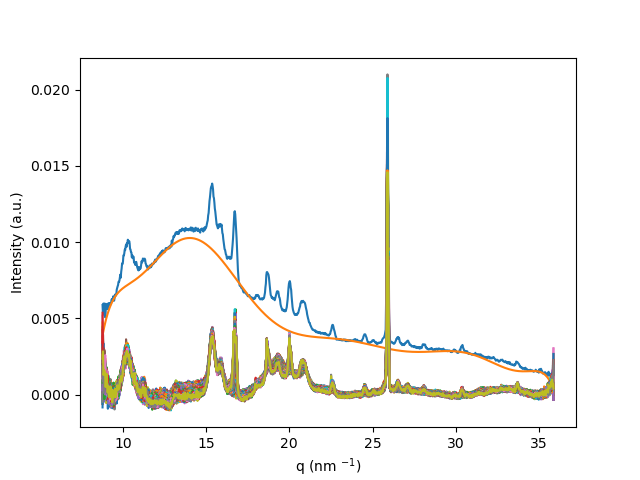

In [55]:
X_data = []
Y_data = []

# Create a average over the first three data files 
plt.figure()
for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary[files].iloc[:,1]
    else:
        x = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 10)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

# Create new file dictionary with corrected spectra
corrected_waxs_files = {}
for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
"""plt.xlim(15,22)
plt.ylim(-0.001,0.008)"""

# Check the plot for determination of two-theta and no of peaks for fitting 

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Peak 1:
 Amplitude = 0.0018 +/- 0.0002
 Center = 18.60
 Width = 0.1898 +/- 0.0321
Peak 2:
 Amplitude = 0.0014 +/- 0.0321
 Center = 19.10
 Width = 0.3672 +/- 0.1053
Peak 3:
 Amplitude = 0.0000 +/- 0.0001
 Center = 19.50
 Width = 0.0171 +/- 857335.2245
Peak 4:
 Amplitude = 0.0018 +/- 0.1053
 Center = 19.90
 Width = 0.2794 +/- 0.0461
Peak 5:
 Amplitude = 0.0020 +/- 0.0004
 Center = 20.80
 Width = 0.3575 +/- 0.0340


Text(0, 0.5, 'Intensity (a.u.)')

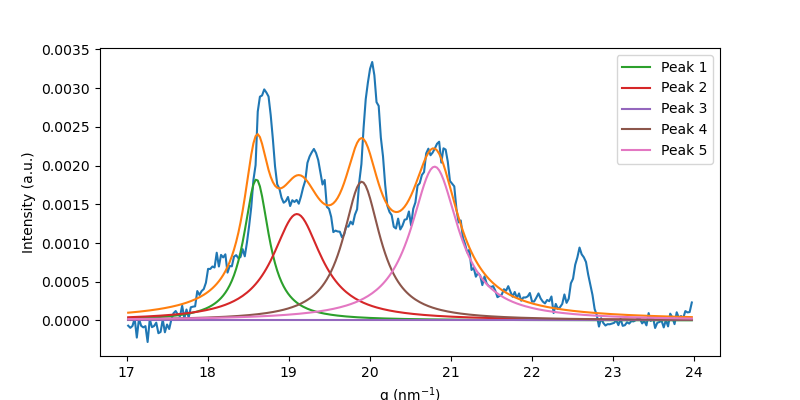

In [56]:
# Filter data between ranges

min_x = 17
max_x = 24

X_positions = corrected_waxs_files[starting_file].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

# Create new list with the filtered data 

x_filtered = []
y_filtered = [] 

for entry in range(start_row, end_row+1):
    x_temp = corrected_waxs_files[2].iloc[entry,0]
    y_temp = corrected_waxs_files[2].iloc[entry,1]
    x_filtered.append(x_temp)
    y_filtered.append(y_temp)

x_filtered = np.array(x_filtered)
y_filtered = np.array(y_filtered)

mean_positions = [18.6, 19.1, 19.5, 19.9, 20.8]
# mean_positions = [18.6, 19.13, 19.9, 20.8]
# mean_positions = [18.6, 19.5, 20.8]
# mean_positions = [19.5]

initial_guess = [0.001, 0.1] * len(mean_positions)

lower_bounds = [0, 0] * (len(mean_positions))
upper_bounds = [np.inf, np.inf] * (len(mean_positions))
bounds = (lower_bounds, upper_bounds)
print(lower_bounds)

popt_lorentz, pcov_lorentz = curve_fit(multi_lorentzian, xdata= x_filtered, ydata= y_filtered, p0 = initial_guess, bounds= bounds)

perr_lorentzian = np.sqrt(np.diag(pcov_lorentz)) # Calculating the errors from the functions


for i in range(len(mean_positions)):
    print(f"Peak {i+1}:")
    print(f" Amplitude = {popt_lorentz[2*i]:.4f} +/- {perr_lorentzian[i]:.4f}")
    print(f" Center = {mean_positions[i]:.2f}")
    print(f" Width = {popt_lorentz[2*i +1]:.4f} +/- {perr_lorentzian[2*i +1]:.4f}")

plt.figure(figsize= (8,4))      

plt.plot(x_filtered, y_filtered)
plt.plot(x_filtered, multi_lorentzian(x_filtered, *popt_lorentz))

#for i in range(0, len(popt_lorentz), 3):
#    plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[i], popt_lorentz[i+1], popt_lorentz[i+2]), label=f'Peak {i//3 + 1}')

for j in range(len(mean_positions)):
    plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[2*j], mean_positions[j], popt_lorentz[2*j+1]), label=f'Peak {j + 1}')
    plt.legend()

plt.xlabel("q (nm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")


In [57]:
# Filter data between ranges
min_x = 17
max_x = 24
X_positions = corrected_waxs_files[starting_file].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

df_curves = pd.DataFrame() # Dataframe to save the fitted peak area and widths 

mean_positions = [18.6, 19.1, 19.5, 19.9, 20.8] # Mean poitions of the peaks 
# mean_positions = [18.6, 19.13, 19.9, 20.8]
# mean_positions = [18.6, 19.5, 20.8]
# mean_positions = [19.5]

initial_guess = [0.005, 0.1] * len(mean_positions) # List for initial guesses for peak amplitude and width 

# Define bounds for amplitude and width Required to keep amplitudes within positive values
lower_bounds = [0, 0] * (len(mean_positions))
upper_bounds = [np.inf, np.inf] * (len(mean_positions))
bounds = (lower_bounds, upper_bounds)

# Create new list with the filtered data 
for file_number in range(starting_file, last_file+1):

    x_filtered = []
    y_filtered = [] 

    for entry in range(start_row, end_row+1):
        x_temp = corrected_waxs_files[file_number].iloc[entry,0]
        y_temp = corrected_waxs_files[file_number].iloc[entry,1]
        x_filtered.append(x_temp)
        y_filtered.append(y_temp)

    x_filtered = np.array(x_filtered)
    y_filtered = np.array(y_filtered)

    popt_lorentz, pcov_lorentz = curve_fit(multi_lorentzian, xdata= x_filtered, ydata= y_filtered, p0 = initial_guess, bounds= bounds)

    perr_lorentzian = np.sqrt(np.diag(pcov_lorentz)) # Calculating the errors from the functions
    temp_dict = {}

    for i in range(len(mean_positions)):
        curve_metrics = [] 
        amplitude = popt_lorentz[2*i]
        w0 = popt_lorentz[2*i +1]
        area = np.pi*amplitude*w0
        width = 2*w0
        curve_metrics.append([area,width])
        temp_dict[i+1] = curve_metrics
        temp_df_curve = pd.DataFrame(temp_dict, index= [file_number])

    df_curves = pd.concat([df_curves, temp_df_curve])
'''    plt.figure("figure 1", figsize= (8,4))      

    plt.plot(x_filtered, y_filtered)
    plt.plot(x_filtered, multi_lorentzian(x_filtered, *popt_lorentz))

    for j in range(len(mean_positions)):
        plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[2*j], mean_positions[j], popt_lorentz[2*j+1]), label=f'Peak {j + 1}')
        plt.legend()
        '''




'    plt.figure("figure 1", figsize= (8,4))      \n\n    plt.plot(x_filtered, y_filtered)\n    plt.plot(x_filtered, multi_lorentzian(x_filtered, *popt_lorentz))\n\n    for j in range(len(mean_positions)):\n        plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[2*j], mean_positions[j], popt_lorentz[2*j+1]), label=f\'Peak {j + 1}\')\n        plt.legend()\n        '

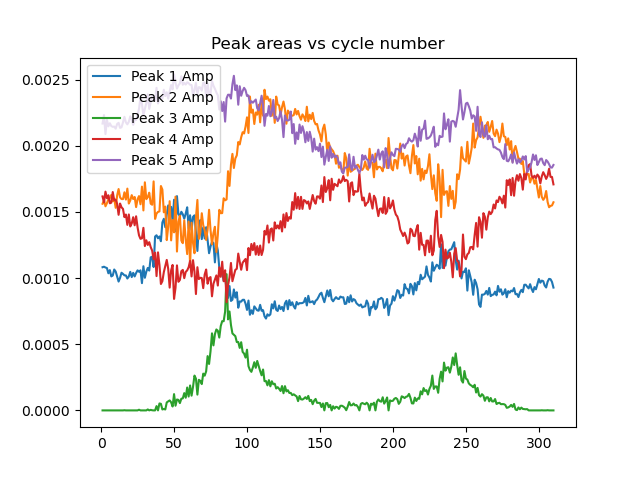

In [58]:
plt.figure()
x1, y1, y2, y3, y4, y5 = [[] for _ in range(6)]

for data in range(1,len(df_curves)):
    x1.append(data)
    y1.append(df_curves.loc[data,1][0])
    y2.append(df_curves.loc[data,2][0])
    y3.append(df_curves.loc[data,3][0])
    y4.append(df_curves.loc[data,4][0])
    y5.append(df_curves.loc[data,5][0])

plt.title("Peak areas vs cycle number")
plt.plot(x1,y1, label = 'Peak 1 Amp' )
plt.plot(x1,y2, label = 'Peak 2 Amp')
plt.plot(x1,y3, label = 'Peak 3 Amp')
plt.plot(x1,y4, label = 'Peak 4 Amp')
plt.plot(x1,y5, label = 'Peak 5 Amp')
plt.legend()

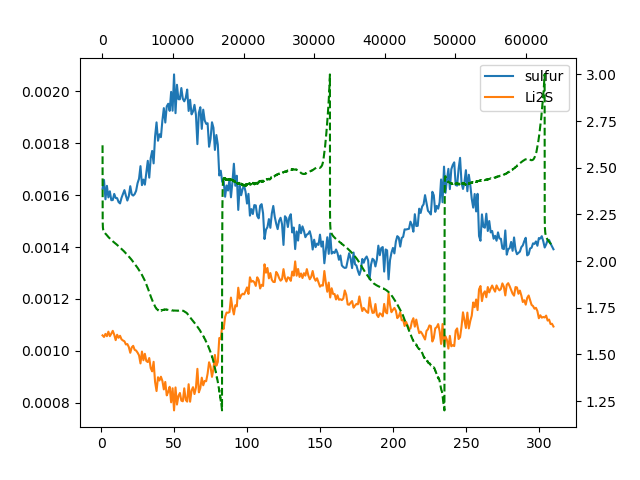

In [59]:
sum_sulfur = [(x + y)/2 for x,y in zip(y1, y5)]
sum_li2S = [(x + y + z)/3 for x,y,z in zip(y2,y3,y4)]

fig, ax1 = plt.subplots()

ax1.plot(x1, sum_sulfur, label = 'sulfur')
ax1.plot(x1, sum_li2S, label = 'Li2S')
ax2 = fig.add_axes(ax1.get_position(), frameon=False)
ax2.plot(Elec_Xdata,Elec_Ydata, 'g--')
ax2.xaxis.set_ticks_position('top')
ax2.yaxis.set_ticks_position('right')

ax1.legend()